In [1]:
# IMPORT LIBRERIE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# =========================
# PARTE 1 - ANALISI PER SINGOLO APPELLO
# =========================

# Inserisci qui il ciclo sugli appelli
# Esempio struttura:

# for appello in lista_appelli:
#     df_appello = df[df['Appello'] == appello]
#     
#     # Statistiche
#     print(df_appello['Voto'].describe())
#     
#     # Grafico distribuzione
#     sns.histplot(df_appello['Voto'], kde=True)
#     plt.title(f'Distribuzione voti - {appello}')
#     plt.show()


In [3]:
# =========================
# PARTE 2 - DATASET COMPLESSIVO
# =========================

# Creazione dataframe finale
df_finale = pd.DataFrame()

# Assicurati che ogni dataframe abbia queste colonne:
# 'Voto', 'Appello'

# Esempio:
# df_temp = ...
# df_temp['Appello'] = 'Gennaio'
# df_finale = pd.concat([df_finale, df_temp], ignore_index=True)

# =========================
# ANALISI COMPLESSIVA
# =========================

# Boxplot voti per appello
sns.boxplot(data=df_finale, x='Appello', y='Voto')
plt.title('Distribuzione voti per appello')
plt.show()


ValueError: Could not interpret value `Appello` for `x`. An entry with this name does not appear in `data`.

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

# =========================
# 1) DATI DI ESEMPIO
# =========================

# Simuliamo i tuoi appelli reali
dati = {
    "appello_id": [1, 2, 3],
    "data_appello": ["23/09/2025", "26/01/2026", "17/06/2026"],
    "voto": [24, 22, 20]  # puoi cambiare questi valori per fare prove
}

df = pd.DataFrame(dati)
df["data_appello"] = pd.to_datetime(df["data_appello"], dayfirst=True)

df

,appello_id,data_appello,voto
0,1,2025-09-23,24
1,2,2026-01-26,22
2,3,2026-06-17,20


In [4]:
# =========================
# 2) FUNZIONE DI PREVISIONE
# =========================

def grafico_previsione(df):
    if df.empty or "voto" not in df.columns or "data_appello" not in df.columns:
        print("DF non valido")
        return None

    df = df.copy()

    # Conversioni
    df["voto_num"] = pd.to_numeric(df["voto"], errors="coerce")
    df["data_appello"] = pd.to_datetime(df["data_appello"], errors="coerce")
    df_validi = df.dropna(subset=["voto_num", "data_appello"])

    # Media per appello (qui ogni appello è unico, ma teniamo la logica generale)
    df_media = df_validi.groupby(["appello_id", "data_appello"])["voto_num"].mean().reset_index()
    df_media = df_media.sort_values("data_appello")

    n_appelli = len(df_media)
    if n_appelli < 2:
        print("Dati insufficienti per una previsione")
        return None

    # Asse X = giorni dal primo appello
    df_media["giorni"] = (df_media["data_appello"] - df_media["data_appello"].min()).dt.days
    X = df_media["giorni"].values.reshape(-1, 1)
    y = df_media["voto_num"].values

    # Distanza media tra appelli (minimo 30 giorni)
    distanze = df_media["data_appello"].diff().dt.days.dropna()
    media_distanza = max(30, int(distanze.mean()))

    # Numero previsioni future = numero appelli storici
    n_future = n_appelli

    future_pred = []
    future_dates = []

    current_X = X.copy()
    current_y = y.copy()
    last_date = df_media["data_appello"].max()

    for i in range(n_future):
        model = LinearRegression()
        model.fit(current_X, current_y)

        next_date = last_date + pd.Timedelta(days=media_distanza)
        last_date = next_date
        future_dates.append(next_date)

        next_day = (next_date - df_media["data_appello"].min()).days
        next_pred = model.predict([[next_day]])[0]

        next_pred = float(np.clip(next_pred, 18, 31))

        future_pred.append(next_pred)

        current_X = np.append(current_X, [[next_day]], axis=0)
        current_y = np.append(current_y, next_pred)

    storico_x = df_media["data_appello"]
    storico_y = df_media["voto_num"]

    previsioni_x = pd.to_datetime(future_dates)
    previsioni_y = future_pred

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=storico_x,
        y=storico_y,
        mode="lines+markers",
        name="Storico",
        line=dict(color="orange")
    ))

    fig.add_trace(go.Scatter(
        x=previsioni_x,
        y=previsioni_y,
        mode="lines+markers",
        name="Previsioni",
        line=dict(color="red")
    ))

    fig.update_layout(
        title="Previsione media voti",
        xaxis_title="Data appello",
        yaxis_title="Media voto",
        yaxis=dict(range=[0, 31])
    )

    fig.show()

    return df_media, list(zip(previsioni_x, previsioni_y))
print(grafico_previsione(df))

(   appello_id data_appello  voto_num  giorni
0           1   2025-09-23      24.0       0
1           2   2026-01-26      22.0     125
2           3   2026-06-17      20.0     267, [(Timestamp('2026-10-28 00:00:00'), 18.0), (Timestamp('2027-03-10 00:00:00'), 18.0), (Timestamp('2027-07-21 00:00:00'), 18.0)])


In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

def previsione_iterativa_senza_date(voti_reali, n_future):
    """
    voti_reali: lista di voti reali, es. [24, 22, 20]
    n_future: quanti punti prevedere
    """

    voti_reali = list(voti_reali)
    storico_x = list(range(1, len(voti_reali) + 1))
    storico_y = voti_reali.copy()

    # dataset corrente
    current_x = np.array(storico_x).reshape(-1, 1)
    current_y = np.array(storico_y, dtype=float)

    future_x = []
    future_y = []

    for i in range(n_future):
        # regressione lineare aggiornata
        model = LinearRegression()
        model.fit(current_x, current_y)

        # prossimo punto X
        next_x = current_x.max() + 1

        # predizione
        next_y = model.predict([[next_x]])[0]

        # limiti realistici
        next_y = float(np.clip(next_y, 18, 31))

        # salva
        future_x.append(next_x)
        future_y.append(next_y)

        # aggiorna dataset
        current_x = np.append(current_x, [[next_x]], axis=0)
        current_y = np.append(current_y, next_y)

    # grafico
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=storico_x,
        y=storico_y,
        mode="lines+markers",
        name="Storico",
        line=dict(color="orange")
    ))

    fig.add_trace(go.Scatter(
        x=future_x,
        y=future_y,
        mode="lines+markers",
        name="Previsioni iterative",
        line=dict(color="red")
    ))

    fig.update_layout(
        title="Previsione iterativa dei voti (senza date)",
        xaxis_title="Numero appello",
        yaxis_title="Media voto",
        yaxis=dict(range=[0, 31])
    )

    fig.show()

    return future_x, future_y
previsione_iterativa_senza_date([24, 22, 20], n_future=5)
print(previsione_iterativa_senza_date([24, 28, 20], n_future=5))


([np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)], [20.0, 18.0, 18.0, 18.0, 18.0])


In [15]:
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

def previsione_iterativa_senza_date(voti_reali, n_future):
    voti_reali = list(voti_reali)

    storico_x = list(range(1, len(voti_reali) + 1))
    storico_y = voti_reali.copy()

    current_x = storico_x.copy()
    current_y = storico_y.copy()

    future_x = []
    future_y = []

    for i in range(n_future):
        # prendi SOLO gli ultimi 3 punti
        x_window = np.array(current_x[-3:]).reshape(-1, 1)
        y_window = np.array(current_y[-3:], dtype=float)

        model = LinearRegression()
        model.fit(x_window, y_window)

        next_x = current_x[-1] + 1
        next_y = model.predict([[next_x]])[0]

        # limiti realistici
        next_y = float(np.clip(next_y, 18, 31))

        # salva
        future_x.append(next_x)
        future_y.append(next_y)

        # aggiorna dataset
        current_x.append(next_x)
        current_y.append(next_y)

    # grafico
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=storico_x,
        y=storico_y,
        mode="lines+markers",
        name="Storico",
        line=dict(color="orange")
    ))

    fig.add_trace(go.Scatter(
        x=future_x,
        y=future_y,
        mode="lines+markers",
        name="Previsioni iterative",
        line=dict(color="red")
    ))

    fig.update_layout(
        title="Previsione iterativa (finestra mobile 3 punti)",
        xaxis_title="Numero appello",
        yaxis_title="Voto",
        yaxis=dict(range=[0, 31])
    )

    fig.show()

    return future_x, future_y

print(previsione_iterativa_senza_date([24, 28, 20], n_future=5))

([4, 5, 6, 7, 8], [20.0, 18.0, 18.0, 18.0, 18.0])


In [3]:
import numpy as np

# esempio: iscritti o qualsiasi serie temporale
data = [15, 15, 21]

n = len(data)
x = np.arange(1, n + 1)
y = np.array(data)

def mean_model(y):
    print("Media semplice:", np.mean(y))
    return np.mean(y)

def regression_model(x, y):
    # y = a + bx
    b, a = np.polyfit(x, y, 1)
    
    next_x = len(x) + 1
    print(f"Regressione lineare: ",a+b*next_x)

    return a + b * next_x

def last_value_model(y):
    print("Ultimo valore:", y[-1])
    return y[-1]

def get_weights(n):
    if n <= 3:
        print("Pochi dati: peso maggiore alla media")
        return 0.5, 0.2, 0.3   # media, regressione, ultimo valore
    elif n <= 10:
        print("Dati moderati: peso maggiore alla regressione")
        return 0.3, 0.5, 0.2
    else:
        print("Dati sufficienti: peso maggiore all'ultimo valore")
        return 0.2, 0.7, 0.1

def ensemble_predict(x, y):
    m = mean_model(y)
    r = regression_model(x, y)
    l = last_value_model(y)

    w_m, w_r, w_l = get_weights(len(y))

    prediction = (w_m * m) + (w_r * r) + (w_l * l)

    return prediction, m, r, l
pred, m, r, l = ensemble_predict(x, y)

print("Media:", m)
print("Regressione:", r)
print("Ultimo valore:", l)
print("Previsione finale:", pred)

Media semplice: 17.0
Regressione lineare:  22.999999999999993
Ultimo valore: 21
Pochi dati: peso maggiore alla media
Media: 17.0
Regressione: 22.999999999999993
Ultimo valore: 21
Previsione finale: 19.4


In [12]:
import numpy as np

# esempio: iscritti o qualsiasi serie temporale
data = [15, 15, 21]

def mean_model(y):
    return np.mean(y)

def regression_model(x, y):
    b, a = np.polyfit(x, y, 1)
    next_x = len(x) + 1
    return a + b * next_x

def last_value_model(y):
    return y[-1]

def get_weights(n):
    if n <= 3:
        return 0.5, 0.2, 0.3   # media, regressione, ultimo valore
    elif n <= 10:
        return 0.3, 0.5, 0.2
    else:
        return 0.2, 0.7, 0.1

def ensemble_predict(y):
    n = len(y)
    x = np.arange(1, n + 1)

    m = mean_model(y)
    r = regression_model(x, y)
    l = last_value_model(y)

    w_m, w_r, w_l = get_weights(n)

    prediction = (w_m * m) + (w_r * r) + (w_l * l)
    return prediction

def forecast_iterativo(data, n_finale):
    serie = data.copy()

    while len(serie) < n_finale:
        next_val = ensemble_predict(serie)
        serie.append(next_val)

    return serie
data = [15, 15, 21, 10, 18, 14, 21, 0, 60]
n_finale = 89

serie_prevista = forecast_iterativo(data, n_finale)

print("Serie finale:", serie_prevista)



Serie finale: [15, 15, 21, 10, 18, 14, 21, 0, 60, np.float64(33.258333333333326), np.float64(29.95441666666666), np.float64(31.86541893939394), np.float64(33.05473147727271), np.float64(34.13673952884615), np.float64(35.16340426376124), np.float64(36.14391341553278), np.float64(37.08333625143139), np.float64(37.985740129884626), np.float64(38.854570624956786), np.float64(39.692786115719755), np.float64(40.50294866220716), np.float64(41.287293604500796), np.float64(42.0477842519444), np.float64(42.786155422985935), np.float64(43.50394848496161), np.float64(44.20253982856464), np.float64(44.883164213280104), np.float64(45.54693406407567), np.float64(46.194855541514315), np.float64(46.82784201781241), np.float64(47.446725450352965), np.float64(48.05226603813507), np.float64(48.645160466094296), np.float64(49.226048980449406), np.float64(49.79552149042253), np.float64(50.354122854371944), np.float64(50.90235747903598), np.float64(51.44069333733917), np.float64(51.96956549166837), np.float6

In [2]:
import numpy as np

def predict_outcomes(
    iscritti_previsti,
    promossi,
    bocciati,
    assenti,
    ritirati,
    pesi=None,          # es: [0.2, 0.3, 0.5]
    normalize=True,     # normalizza probabilità
    round_values=True   # arrotonda output
):
    """
    Predice promossi, bocciati, assenti e ritirati dato N iscritti.

    Parameters:
    - iscritti_previsti: int
    - promossi, bocciati, assenti, ritirati: liste storiche
    - pesi: lista pesi (opzionale, stessa lunghezza dei dati)
    - normalize: forza somma probabilità = 1
    - round_values: arrotonda risultati finali

    Returns:
    - dict con risultati
    """

    # --- STEP 1: conversione in array ---
    promossi = np.array(promossi)
    bocciati = np.array(bocciati)
    assenti  = np.array(assenti)
    ritirati = np.array(ritirati)

    iscritti = promossi + bocciati + assenti + ritirati

    # --- STEP 2: calcolo proporzioni ---
    p_prom = promossi / iscritti
    p_bocc = bocciati / iscritti
    p_ass  = assenti  / iscritti
    p_rit  = ritirati / iscritti

    # --- STEP 3: pesi ---
    if pesi is None:
        pesi = np.ones(len(iscritti)) / len(iscritti)
    else:
        pesi = np.array(pesi)
        pesi = pesi / np.sum(pesi)  # normalizza

    # --- STEP 4: media pesata ---
    p_prom_mean = np.sum(pesi * p_prom)
    p_bocc_mean = np.sum(pesi * p_bocc)
    p_ass_mean  = np.sum(pesi * p_ass)
    p_rit_mean  = np.sum(pesi * p_rit)

    # --- STEP 5: normalizzazione (sicurezza) ---
    if normalize:
        total = p_prom_mean + p_bocc_mean + p_ass_mean + p_rit_mean
        p_prom_mean /= total
        p_bocc_mean /= total
        p_ass_mean  /= total
        p_rit_mean  /= total

    # --- STEP 6: applica a N ---
    prom_pred = iscritti_previsti * p_prom_mean
    bocc_pred = iscritti_previsti * p_bocc_mean
    ass_pred  = iscritti_previsti * p_ass_mean
    rit_pred  = iscritti_previsti * p_rit_mean

    # --- STEP 7: arrotondamento ---
    if round_values:
        prom_pred = round(prom_pred)
        bocc_pred = round(bocc_pred)
        ass_pred  = round(ass_pred)
        rit_pred  = round(rit_pred)

    return {
        "iscritti": iscritti_previsti,
        "promossi": prom_pred,
        "bocciati": bocc_pred,
        "assenti": ass_pred,
        "ritirati": rit_pred,
        "probabilità": {
            "promossi": p_prom_mean,
            "bocciati": p_bocc_mean,
            "assenti": p_ass_mean,
            "ritirati": p_rit_mean
        }
    }
print(predict_outcomes(100, [10, 20, 30], [5, 15, 25], [10, 20, 30], [5, 15, 25]))

{'iscritti': 100, 'promossi': 30, 'bocciati': 20, 'assenti': 30, 'ritirati': 20, 'probabilità': {'promossi': np.float64(0.2972582972582973), 'bocciati': np.float64(0.20274170274170278), 'assenti': np.float64(0.2972582972582973), 'ritirati': np.float64(0.20274170274170278)}}


In [5]:
import numpy as np

# -----------------------------
# 1. COMPONENTI BASE
# -----------------------------

def mean_model(medie):
    return np.mean(medie)

def last_value_model(medie):
    return medie[-1]

def regression_model(promossi, iscritti, medie):
    # pass_rate
    p = np.array(promossi) / np.array(iscritti)
    y = np.array(medie)

    # regressione: y = a + b*p
    X = np.vstack([np.ones(len(p)), p]).T
    coeffs = np.linalg.lstsq(X, y, rcond=None)[0]

    return coeffs  # a, b


def predict_regression(coeffs, prom_prev, iscritti_prev):
    p = prom_prev / iscritti_prev
    a, b = coeffs
    return a + b * p


# -----------------------------
# 2. PESI ADATTIVI
# -----------------------------

def get_weights(n):
    if n <= 5:
        return 0.5, 0.2, 0.3   # media, regressione, last
    elif n <= 20:
        return 0.3, 0.5, 0.2
    else:
        return 0.2, 0.7, 0.1


# -----------------------------
# 3. MODELLO COMPLETO
# -----------------------------

def predict_exam_mean(
    promossi,
    iscritti,
    medie,
    prom_prev,
    iscritti_prev
):
    """
    Predice la media futura combinando:
    - media storica
    - regressione su pass_rate
    - ultimo valore
    """

    n = len(medie)

    # --- componenti ---
    m = mean_model(medie)
    l = last_value_model(medie)

    coeffs = regression_model(promossi, iscritti, medie)
    r = predict_regression(coeffs, prom_prev, iscritti_prev)

    # --- pesi ---
    w_m, w_r, w_l = get_weights(n)

    # --- ensemble ---
    prediction = (w_m * m) + (w_r * r) + (w_l * l)

    return {
        "media_predetta": prediction,
        "componenti": {
            "media_storica": m,
            "regressione": r,
            "ultimo_valore": l
        },
        "pesi": {
            "media": w_m,
            "regressione": w_r,
            "ultimo": w_l
        }
    }
# Esempio di utilizzo
result = predict_exam_mean(
    promossi=[10, 9, 8],
    iscritti=[15, 15, 21],
    medie=[23.1, 25.5, 13.4],
    prom_prev=10,          # dal modello precedente
    iscritti_prev=20       # dal modello iscritti
)

print(result)

{'media_predetta': np.float64(18.100390166892197), 'componenti': {'media_storica': np.float64(20.666666666666668), 'regressione': np.float64(18.73528416779431), 'ultimo_valore': 13.4}, 'pesi': {'media': 0.5, 'regressione': 0.2, 'ultimo': 0.3}}


In [ ]:
#codice effettivo
#Previsione delle medie

#1.componenti
def mean_model(medie):
    return np.mean(medie)

def last_value_model(medie):
    return medie[-1]

def regression_model_medie(promossi, iscritti, medie):
    # pass_rate
    p = np.array(promossi) / np.array(iscritti)
    y = np.array(medie)

    # regressione: y = a + b*p
    X = np.vstack([np.ones(len(p)), p]).T
    coeffs = np.linalg.lstsq(X, y, rcond=None)[0]

    return coeffs  # a, b


def predict_regression(coeffs, prom_prev, iscritti_prev):
    p = prom_prev / iscritti_prev
    a, b = coeffs
    return a + b * p

#2.pesi adattivi
def get_weights(n):
    if n <= 5:
        return 0.5, 0.2, 0.3   # media, regressione, last
    elif n <= 20:
        return 0.3, 0.5, 0.2
    else:
        return 0.2, 0.7, 0.1

#3. modello completo: ensamable di media storica + regressione + ultimo valore
def predict_exam_mean(
    promossi,
    iscritti,
    medie,
    prom_prev,
    iscritti_prev
):
    """
    Predice la media futura combinando:
    - media storica
    - regressione su pass_rate
    - ultimo valore
    """

    n = len(medie)

    # --- componenti ---
    m = mean_model(medie)
    l = last_value_model(medie)

    coeffs = regression_model_medie(promossi, iscritti, medie)
    r = predict_regression(coeffs, prom_prev, iscritti_prev)

    # --- pesi ---
    w_m, w_r, w_l = get_weights(n)

    # --- ensemble ---
    prediction = (w_m * m) + (w_r * r) + (w_l * l)

    return {
        "media_predetta": prediction,
        "componenti": {
            "media_storica": m,
            "regressione": r,
            "ultimo_valore": l
        },
        "pesi": {
            "media": w_m,
            "regressione": w_r,
            "ultimo": w_l
        }
    }

def forecast_exam_means(promossi, iscritti, medie, n_finale):
    """
    Genera una serie predetta delle medie fino a n_finale.
    """
    prom = promossi.copy()
    isc = iscritti.copy()
    med = medie.copy()
    print("\n=== PREVISIONE ITERATIVA MEDIE D'ESAME ===")
    print("Promossi storici:", prom)
    print("Iscritti storici:", isc) 
    print("Medie storiche:", med)

    while len(med) < n_finale:
        pred = predict_exam_mean(
            prom,
            isc,
            med,
            prom_prev=prom[-1],
            iscritti_prev=isc[-1]
        )["media_predetta"]

        # aggiungo la previsione
        med.append(pred)

        # opzionale: puoi anche prevedere promossi/iscritti
        # per ora li manteniamo costanti
        prom.append(prom[-1])
        isc.append(isc[-1])
    print("Medie previste:", med)

    return med

def grafico_previsione_medie(df, n_future):
    df["voto_num"] = pd.to_numeric(df["voto"], errors="coerce")
    df_media = df.groupby("appello_id")["voto_num"].mean().reset_index()

    medie_storiche = df_media["voto_num"].tolist()
    etichette_storiche = df_media["appello_id"].tolist()

    promossi = df[df["tipo"] == "promosso"].groupby("appello_id").size().tolist()
    iscritti = df.groupby("appello_id").size().tolist()

    # Previsioni future
    n_finale = len(medie_storiche) + n_future
    medie_predette = forecast_exam_means(promossi, iscritti, medie_storiche, n_finale)

    n_storico = len(medie_storiche)
    n_pred = len(medie_predette) - n_storico

    # X storiche e future
    x_storico = list(range(1, n_storico + 1))
    x_pred = list(range(n_storico + 1, n_storico + 1 + n_pred))

    # Etichette asse X
    etichette_future = [f"appello futuro {i+1}" for i in range(n_pred)]
    etichette_x = etichette_storiche + etichette_future
    tickvals = x_storico + x_pred

    fig = go.Figure()

    #storico
    for i in range(len(medie_storiche) - 1):
        y0 = medie_storiche[i]
        y1 = medie_storiche[i+1]
        colore_linea = "green" if y1 > y0 else "red"

        fig.add_trace(go.Scatter(
            x=[x_storico[i], x_storico[i+1]],
            y=[y0, y1],
            mode="lines",
            line=dict(color=colore_linea, width=3),
            showlegend=False,
            hoverinfo="skip"
        ))

    #pallini storici (colori dinamici)
    fig.add_trace(go.Scatter(
        x=x_storico,
        y=medie_storiche,
        mode="markers",
        marker=dict(
            size=10,
            color=["red" if v < 18 else "green" for v in medie_storiche]
        ),
        name="Medie storiche",
        hovertemplate="Storico<br>Appello: %{x}<br>Media: %{y:.2f}<extra></extra>"
    ))

    #previsione (colori dinamici)
    future_vals = medie_predette[n_storico:]

    for i in range(len(future_vals) - 1):
        y0 = future_vals[i]
        y1 = future_vals[i+1]
        colore_linea = "green" if y1 > y0 else "red"

        fig.add_trace(go.Scatter(
            x=[x_pred[i], x_pred[i+1]],
            y=[y0, y1],
            mode="lines",
            line=dict(color=colore_linea, width=3, dash="dash"),
            showlegend=False,
            hoverinfo="skip"
        ))

    #pallini predetti
    fig.add_trace(go.Scatter(
        x=x_pred,
        y=future_vals,
        mode="markers",
        marker=dict(
            size=10,
            color=["red" if v < 18 else "orange" for v in future_vals]
        ),
        name="Medie predette",
        hovertemplate="Previsione<br>Appello: %{x}<br>Media: %{y:.2f}<extra></extra>"
    ))

    #collegamento tra ultimo storico e primo predetto
    if n_pred > 0:
        fig.add_trace(go.Scatter(
            x=[x_storico[-1], x_pred[0]],
            y=[medie_storiche[-1], future_vals[0]],
            mode="lines",
            line=dict(color="gray", width=2, dash="dot"),
            showlegend=False
        ))

    #area di confidenza ±5%
    tutte = medie_predette
    upper = [v * 1.05 for v in tutte]
    lower = [v * 0.95 for v in tutte]

    fig.add_trace(go.Scatter(
        x=tickvals,
        y=upper,
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    ))

    fig.add_trace(go.Scatter(
        x=tickvals,
        y=lower,
        mode="lines",
        fill="tonexty",
        fillcolor="rgba(200,200,200,0.2)",
        line=dict(width=0),
        name="Intervallo ±5%",
        hoverinfo="skip"
    ))


    #linea "Inizio previsione"
    fig.add_vline(
        x=n_storico + 0.5,
        line_width=2,
        line_dash="dot",
        line_color="gray"
    )

    fig.add_annotation(
        x=n_storico + 0.5,
        y=max(medie_predette),
        text="Inizio previsione",
        showarrow=False,
        yshift=10,
        font=dict(color="gray", size=10)
    )

    #asse x con etichette storiche + future
    fig.update_xaxes(
        tickmode="array",
        tickvals=tickvals,
        ticktext=etichette_x
    )

    fig.update_layout(
        title="Andamento delle Medie d'Esame (storico + previsione)",
        xaxis_title="Appello",
        yaxis_title="Media",
        template="plotly_white",
        legend=dict(x=0.01, y=0.99)
    )

    return fig.to_plotly_json()

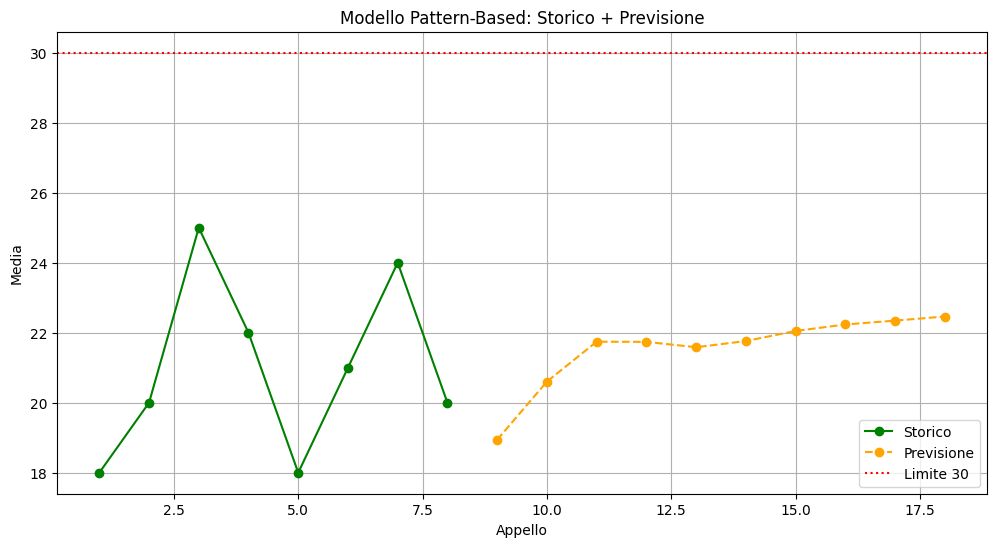

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# MODELLO PATTERN-BASED
# ============================

def predict_exam_mean(prom, isc, med, prom_prev, iscritti_prev):
    # 1) Media mobile degli ultimi 3 valori
    if len(med) >= 3:
        ma3 = np.mean(med[-3:])
    else:
        ma3 = np.mean(med)

    # 2) Trend lineare su tutta la serie
    X = np.arange(len(med))
    Y = np.array(med)
    if len(med) >= 2:
        coeffs = np.polyfit(X, Y, 1)
        trend_pred = coeffs[0] * len(med) + coeffs[1]
    else:
        trend_pred = med[-1]

    # 3) Dinamica: differenza (delta)
    if len(med) >= 2:
        delta = med[-1] - med[-2]
    else:
        delta = 0

    # 4) Accelerazione: differenza delle differenze
    if len(med) >= 3:
        accel = (med[-1] - med[-2]) - (med[-2] - med[-3])
    else:
        accel = 0

    # 5) Pass-rate
    ratio = prom_prev / iscritti_prev if iscritti_prev > 0 else 1
    ratio_adj = 18 + (ratio * 12)  # 18–30

    # 6) Ensemble pattern-based
    pred = (
        0.30 * ma3 +
        0.25 * trend_pred +
        0.20 * (med[-1] + delta) +
        0.15 * (med[-1] + delta + accel) +
        0.10 * ratio_adj
    )

    # 7) Limiti realistici
    pred = max(18, min(pred, 30))

    return pred


# ============================
# FUNZIONE DI PREVISIONE ITERATIVA
# ============================

def forecast_exam_means(medie, promossi, iscritti, n_future):
    med = medie.copy()
    prom = promossi.copy()
    isc = iscritti.copy()

    for _ in range(n_future):
        pred = predict_exam_mean(
            prom, isc, med,
            prom_prev=prom[-1],
            iscritti_prev=isc[-1]
        )
        med.append(pred)
        prom.append(prom[-1])  # costanti
        isc.append(isc[-1])

    return med


# ============================
# DATI DI ESEMPIO
# ============================

medie_storiche = [18, 20, 25, 22, 18, 21, 24, 20]
promossi = [10]*len(medie_storiche)
iscritti = [20]*len(medie_storiche)

n_future = 10

# ============================
# CALCOLO PREVISIONE
# ============================

medie_complete = forecast_exam_means(
    medie_storiche,
    promossi,
    iscritti,
    n_future
)

# ============================
# GRAFICO
# ============================

plt.figure(figsize=(12,6))

x_storico = np.arange(1, len(medie_storiche)+1)
x_pred = np.arange(len(medie_storiche)+1, len(medie_complete)+1)

# storico
plt.plot(x_storico, medie_storiche, marker="o", color="green", label="Storico")

# previsione
plt.plot(x_pred, medie_complete[len(medie_storiche):], marker="o", color="orange", linestyle="--", label="Previsione")

# limite massimo
plt.axhline(30, color="red", linestyle=":", label="Limite 30")

plt.title("Modello Pattern-Based: Storico + Previsione")
plt.xlabel("Appello")
plt.ylabel("Media")
plt.grid(True)
plt.legend()
plt.show()